# Homework 2: Emergent communication models

This homework assignment is to be completed in groups. It is due on December 18, 2025 (midnight). Please upload *all files you created or modified* to the homework folder of your group in studIP.

Group number:

Names:

*General note: It is permitted to use AI tools for coding. Please refer to the uploaded manual `AI_Tools_Guidelines` for recommended ways how to use AI to advance your studies in a way that supports your learning. That means that you should not be satisfied if an AI tool hands you a working version of your code, but that you should put in effort to understand how exactly the problem is solved. Another note of caution: What might work for large programming languages like Python, does not necessarily work for Stan. Check your code carefully and do NOT blindly trust AI.*

## Introduction
In the past weeks, you learned about classical neural network approaches to modeling language, about Reinforcement learning and how these two can be combined with the aim of modeling communication in the emergent communication modeling framework.
The goal of this homework assignment is to learn to apply these models. You will be working with a Github repository of my own research. Learning how to work with this repository will qualify you for conducting your study project or thesis within this project.
Below, you receive a sample project and are guided through the steps of conducting it. For all steps, it is expected that you comment your code, explain what you are doing and why, and interpret all your outcomes and results. 

## 1) Creating the environment and installing packages (non-graded)
This is a prerequisite for the following tasks and is therefore non-graded. Please let me know if you run into problems with installing everything. Follow the installation guide in the [emergent-abstractions repository](https://github.com/kristinakobrock/emergent-abstractions/tree/main) and validate that you can run the training (with a small number of epochs and dataset). Follow the tutorial in the [Tutorial Github repository](https://github.com/kristinakobrock/tutorial-emergent-abstractions/tree/main) to make yourself familiar with the code.

For the following tasks, you can either work directly with the main repository (recommended) or work with the tutorial code.

```bash
uv init --bare -p 3.9 .
uv add -r .\emergent-abstractions\requirements.txt
uv add git+https://github.com/facebookresearch/EGG.git
uv add ipykernel
```


## 2) Dataset (18 points)
The goal is to implement a hierarchical dataset that follows the following logic from the paper by Hawkins et al., 2018: [Emerging abstractions](https://escholarship.org/uc/item/81s4d7fv)
<img src="img/hierarchy.png" width="400"/>
It differs from the default dataset because the default dataset includes all combinations of objects without implementing a hierarchy. Consider the following example for the default dataset with 3 attributes and 3 values. Concepts are implemented as tuples of objects and fixed vectors which indicate which attributes are relevant to the concept, e.g. ([[2,1,1],[1,0,1],[1,2,1]],(0,0,1)). Where the fixed vector (0,0,1) indicates that only the first attribute is relevant to the concept. [2,1,1],[1,0,1],[1,2,1] are possible objects that satisfy this constraint. You can think of the objects as being a small red circle, a large blue circle and a large green circle - all belonging to the concept 'circle'. Now, in the default dataset, all combinations of attributes are possible, i.e. the higher-level concept don't need to be circles, but could also be the color dimension or the size dimension by specifying the fixed vector as (1,0,0) or (0,1,0). While this certainly makes a lot of sense for compositional features as the ones used here, natural concepts are structured in taxonomic hierarchies (e.g., dalmatian, dog, animal). The goal here is to implement a hierarchical dataset.

### 2.1) Adapting the dataset (12 points)
Adapt the function `get_fixed_vectors` in `dataset.py` to account for hierarchically structured concepts.
Your solution should work for varying dataset sizes and be neatly integrated with the currently available code. Specify a folder where the results for this experiment should be saved to.

### 2.2) Creating the datasets (6 points)
Use the script `pickle_ds.py` to construct 3 datasets with the following attribute-value combinations D(attributes, values):
- D(3,4)
- D(4,4)
- D(3,8)

In [1]:
!python pickle_ds.py --dimensions 4 4 4 --hierarchical True
!python pickle_ds.py --dimensions 4 4 4 4 --hierarchical True
!python pickle_ds.py --dimensions 8 8 8 --hierarchical True
!python pickle_ds.py --dimensions 4 4 4 --hierarchical False
!python pickle_ds.py --dimensions 4 4 4 4 --hierarchical False
!python pickle_ds.py --dimensions 8 8 8 --hierarchical False

Creating train_ds and val_ds...
100%|██████████████████████████████████████████| 67/67 [00:00<00:00, 118.64it/s]

Creating test_ds...
100%|██████████████████████████████████████████| 17/17 [00:00<00:00, 116.86it/s]
Data set is saved as: data/dim(3,4)_sf10_hierarchical.ds
Creating train_ds and val_ds...
100%|█████████████████████████████████████████| 272/272 [00:04<00:00, 58.91it/s]

Creating test_ds...
100%|███████████████████████████████████████████| 68/68 [00:01<00:00, 60.21it/s]
Data set is saved as: data/dim(4,4)_sf10_hierarchical.ds
Creating train_ds and val_ds...
100%|█████████████████████████████████████████| 467/467 [00:07<00:00, 66.63it/s]

Creating test_ds...
100%|█████████████████████████████████████████| 117/117 [00:01<00:00, 69.33it/s]
Data set is saved as: data/dim(3,8)_sf10_hierarchical.ds
Creating train_ds and val_ds...
100%|██████████████████████████████████████████| 67/67 [00:00<00:00, 124.67it/s]

Creating test_ds...
100%|██████████████████████████████████████████| 1

In [1]:
import torch
import pandas as pd
import seaborn


# [3,4] 
with open('data/dim(3,4)_sf10_hierarchical.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_3_4 = set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_3_4)} unique fixed vectors:")
for fixed in sorted(unique_fixed_3_4):
    print(" ", fixed)

with open('data/dim(3,4)_sf10.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_3_4 = set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_3_4)} unique fixed vectors:")
for fixed in sorted(unique_fixed_3_4):
    print(" ", fixed)

# [4,4]     
with open('data/dim(4,4)_sf10_hierarchical.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_4_4 = set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_4_4)} unique fixed vectors:")
for fixed in sorted(unique_fixed_4_4):
    print(" ", fixed)
    
with open('data/dim(4,4)_sf10.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_4_4 = set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_4_4)} unique fixed vectors:")
for fixed in sorted(unique_fixed_4_4):
    print(" ", fixed)

# [3,8] 
with open('data/dim(3,8)_sf10_hierarchical.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_8_3= set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_8_3)} unique fixed vectors:")
for fixed in sorted(unique_fixed_8_3):
    print(" ", fixed)

with open('data/dim(3,8)_sf10.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_8_3= set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_8_3)} unique fixed vectors:")
for fixed in sorted(unique_fixed_8_3):
    print(" ", fixed)

Is hierarchical? True
Number of concepts: 84

Found 3 unique fixed vectors:
  (0, 0, 1)
  (0, 1, 1)
  (1, 1, 1)
Is hierarchical? False
Number of concepts: 124

Found 7 unique fixed vectors:
  (0, 0, 1)
  (0, 1, 0)
  (0, 1, 1)
  (1, 0, 0)
  (1, 0, 1)
  (1, 1, 0)
  (1, 1, 1)
Is hierarchical? True
Number of concepts: 340

Found 4 unique fixed vectors:
  (0, 0, 0, 1)
  (0, 0, 1, 1)
  (0, 1, 1, 1)
  (1, 1, 1, 1)
Is hierarchical? False
Number of concepts: 624

Found 15 unique fixed vectors:
  (0, 0, 0, 1)
  (0, 0, 1, 0)
  (0, 0, 1, 1)
  (0, 1, 0, 0)
  (0, 1, 0, 1)
  (0, 1, 1, 0)
  (0, 1, 1, 1)
  (1, 0, 0, 0)
  (1, 0, 0, 1)
  (1, 0, 1, 0)
  (1, 0, 1, 1)
  (1, 1, 0, 0)
  (1, 1, 0, 1)
  (1, 1, 1, 0)
  (1, 1, 1, 1)
Is hierarchical? True
Number of concepts: 584

Found 3 unique fixed vectors:
  (0, 0, 1)
  (0, 1, 1)
  (1, 1, 1)
Is hierarchical? False
Number of concepts: 728

Found 7 unique fixed vectors:
  (0, 0, 1)
  (0, 1, 0)
  (0, 1, 1)
  (1, 0, 0)
  (1, 0, 1)
  (1, 1, 0)
  (1, 1, 1)


## 3) Model simulations (12 points)
Think about which conditions (i.e., settings) you need to compare to discuss whether the implementation of the hierarchical dataset has any measurable impact on the emerging language. Specify which conditions you will compare and why and state your hypotheses. Simulate five runs for each of the datasets and each of the conditions. For hyperparameters, it is recommended to either stick to hyperparameters that were used before (check publications or default settings) or do a grid search over hyperparameters if you expect different hyperparameters to work better.

### Default Runs

#### DIM(3,4)_SF10

In [ ]:
!python train.py --load_dataset "dim(3,4)_sf10.ds" --random_seed 0 --save True

data loaded from: data/dim(3,4)_sf10.ds
vocab size 16
message length 3
{"loss": 0.6735930442810059, "acc": 0.5605096220970154, "length": 3.4660444259643555, "mode": "train", "epoch": 1}
{"loss": 0.5851393342018127, "acc": 0.6715277433395386, "length": 4.0, "mode": "test", "epoch": 1}
{"loss": 0.5401543974876404, "acc": 0.7341485619544983, "length": 3.948493003845215, "mode": "train", "epoch": 2}
{"loss": 0.5307715535163879, "acc": 0.7655380964279175, "length": 4.0, "mode": "test", "epoch": 2}


In [ ]:
!python train.py --load_dataset "dim(3,4)_sf10.ds" --random_seed 1 --save True

In [ ]:
!python train.py --load_dataset "dim(3,4)_sf10.ds" --random_seed 2 --save True

In [ ]:
!python train.py --load_dataset "dim(3,4)_sf10.ds" --random_seed 3 --save True

In [ ]:
!python train.py --load_dataset "dim(3,4)_sf10.ds" --random_seed 4 --save True

#### DIM(4,4)_SF10

In [ ]:
!python train.py --load_dataset "dim(4,4)_sf10.ds" --random_seed 0 --save True

In [ ]:
!python train.py --load_dataset "dim(4,4)_sf10.ds" --random_seed 1 --save True

In [ ]:
!python train.py --load_dataset "dim(4,4)_sf10.ds" --random_seed 2 --save True

In [10]:
!python train.py --load_dataset "dim(4,4)_sf10.ds" --random_seed 3 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [11]:
!python train.py --load_dataset "dim(4,4)_sf10.ds" --random_seed 4 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


#### DIM(3,8)_SF10

In [12]:
!python train.py --load_dataset "dim(3,8)_sf10.ds" --random_seed 0 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [13]:
!python train.py --load_dataset "dim(3,8)_sf10.ds" --random_seed 1 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [14]:
!python train.py --load_dataset "dim(3,8)_sf10.ds" --random_seed 2 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [15]:
!python train.py --load_dataset "dim(3,8)_sf10.ds" --random_seed 3 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [16]:
!python train.py --load_dataset "dim(3,8)_sf10.ds" --random_seed 4 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


### Hierarchical Runs

#### DIM(3,4)_SF10

In [17]:
!python train.py --load_dataset "dim(3,4)_sf10_hierarchical.ds" --random_seed 0 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [18]:
!python train.py --load_dataset "dim(3,4)_sf10_hierarchical.ds" --random_seed 1 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [19]:
!python train.py --load_dataset "dim(3,4)_sf10_hierarchical.ds" --random_seed 2 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [20]:
!python train.py --load_dataset "dim(3,4)_sf10_hierarchical.ds" --random_seed 3 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [21]:
!python train.py --load_dataset "dim(3,4)_sf10_hierarchical.ds" --random_seed 4 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


#### DIM(4,4)_SF10

In [22]:
!python train.py --load_dataset "dim(4,4)_sf10_hierarchical.ds" --random_seed 0 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [23]:
!python train.py --load_dataset "dim(4,4)_sf10_hierarchical.ds" --random_seed 1 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [24]:
!python train.py --load_dataset "dim(4,4)_sf10_hierarchical.ds" --random_seed 2 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [25]:
!python train.py --load_dataset "dim(4,4)_sf10_hierarchical.ds" --random_seed 3 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [26]:
!python train.py --load_dataset "dim(4,4)_sf10_hierarchical.ds" --random_seed 4 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


#### DIM(3,8)_SF10

In [27]:
!python train.py --load_dataset "dim(3,8)_sf10_hierarchical.ds" --random_seed 0 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [28]:
!python train.py --load_dataset "dim(3,8)_sf10_hierarchical.ds" --random_seed 1 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [29]:
!python train.py --load_dataset "dim(3,8)_sf10_hierarchical.ds" --random_seed 2 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [30]:
!python train.py --load_dataset "dim(3,8)_sf10_hierarchical.ds" --random_seed 3 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


In [31]:
!python train.py --load_dataset "dim(3,8)_sf10_hierarchical.ds" --random_seed 4 --save True

python: can't open file '/Users/asuka/Downloads/train.py': [Errno 2] No such file or directory


### PLOT

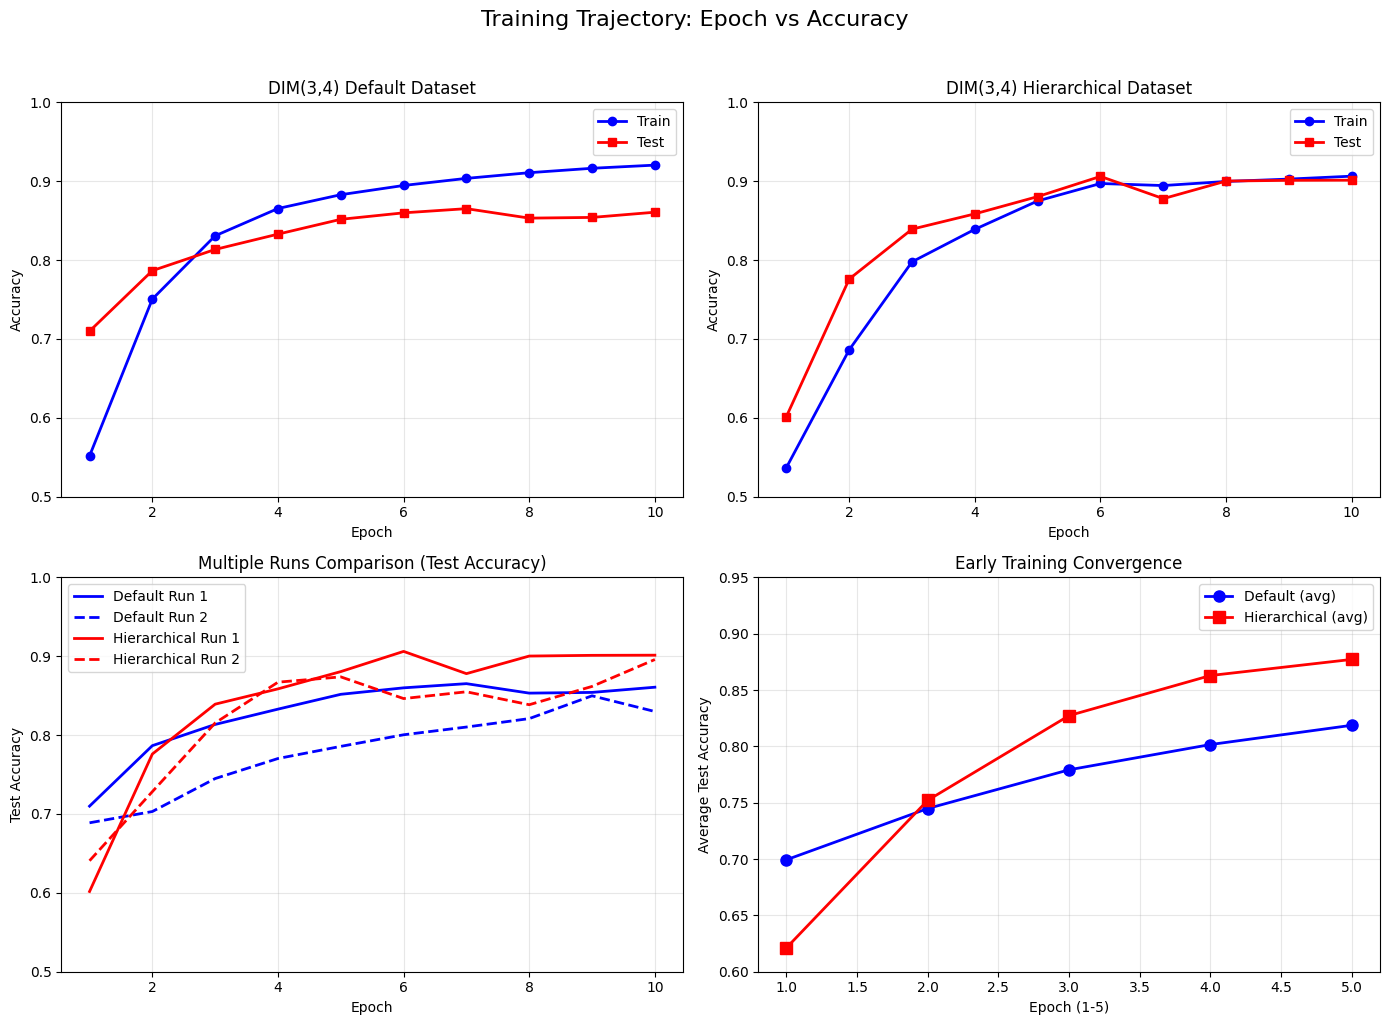

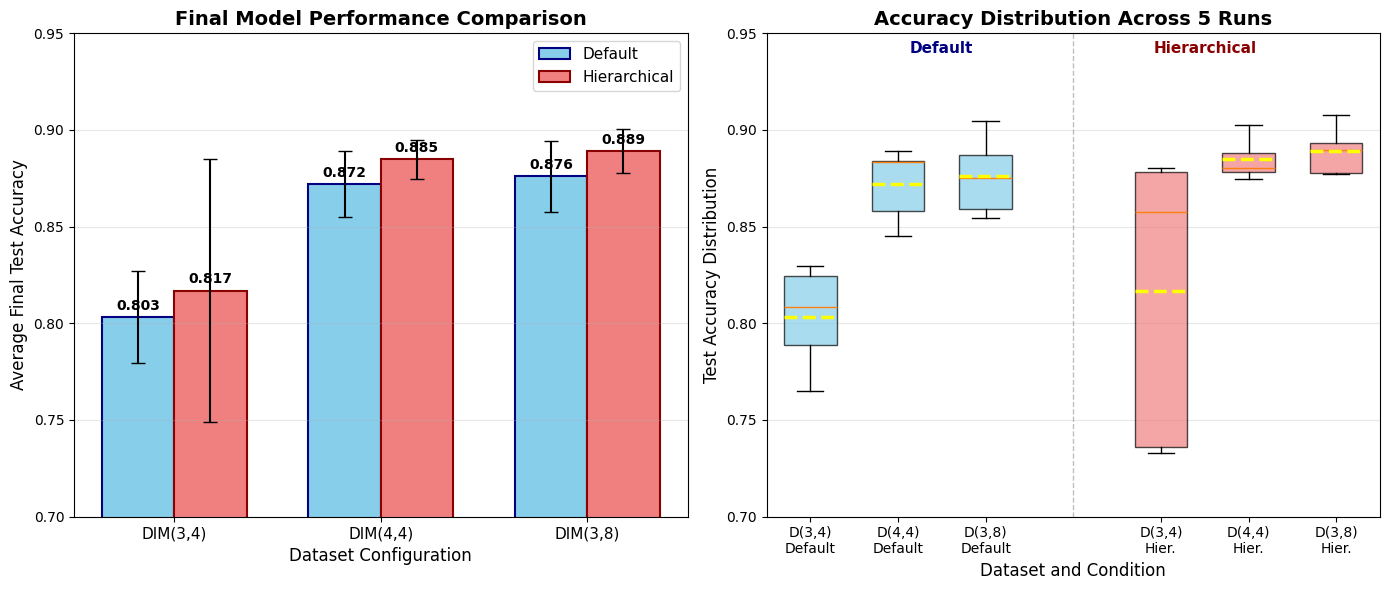

PERFORMANCE SUMMARY TABLE
Dataset         Condition       Mean Acc     Std Dev      Min        Max       
----------------------------------------------------------------------
DIM(3,4)        Default         0.8032       0.0239       0.7648     0.8297    
DIM(3,4)        Hierarchical    0.8169       0.0678       0.7329     0.8803    
DIM(4,4)        Default         0.8720       0.0172       0.8452     0.8892    
DIM(4,4)        Hierarchical    0.8848       0.0100       0.8747     0.9028    
DIM(3,8)        Default         0.8762       0.0184       0.8546     0.9046    
DIM(3,8)        Hierarchical    0.8892       0.0114       0.8770     0.9080    

PERFORMANCE CHANGE ANALYSIS (Hierarchical vs Default)
DIM(3,4): Default=0.8032, Hierarchical=0.8169, Change: ↑ 0.0137 (+1.70%)
DIM(4,4): Default=0.8720, Hierarchical=0.8848, Change: ↑ 0.0128 (+1.46%)
DIM(3,8): Default=0.8762, Hierarchical=0.8892, Change: ↑ 0.0130 (+1.48%)


In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Performance
from utils.load_results import *
from utils.plot_helpers import *
from utils.analysis_from_interaction import *

RESULTS_DIR = "results/(3,4)_game_size_10_vsf_3"
BASE = str(RESULTS_DIR + "/standard/")
RUN_MAP = {
    "(3,4)_nonhier": [0],
    "(3,4)_hier":    [1],
    "(3,8)_nonhier": [2],
    "(3,8)_hier":    [3],
    "(4,4)_nonhier": [4],
    "(4,4)_hier":    [5],
}

BASE_PATH = "results/(3,4)_game_size_10_vsf_3"

all_accuracies = load_accuracies(
    all_paths=[BASE_PATH],
    n_runs=30,
    n_epochs=10,
    val_steps=1,
    context_unaware=False
)


def regroup_by_runs(raw, run_map, key):
    """
    raw[key] shape: (1, n_runs, T)
    returns: dict[condition] -> np.array(runs, T)
    """
    out = {}
    data = raw[key][0]  # drop dataset dimension
    for cond, runs in run_map.items():
        out[cond] = data[runs]
    return out

train_acc = regroup_by_runs(all_accuracies, RUN_MAP, "train_acc")
val_acc   = regroup_by_runs(all_accuracies, RUN_MAP, "val_acc")

def plot_conditions(train_dict, val_dict, order, titles):
    # Make sure each run is a 1D array of length n_epochs
    train_list = [np.ravel(train_dict[k]) for k in order]  # ravel flattens to 1D
    val_list   = [np.ravel(val_dict[k]) for k in order]
    plot_indices=tuple(range(1, len(order) + 1))

    plot_training_trajectory(
        train_list,
        val_list,
        n_epochs=n_epochs,
        plot_indices=plot_indices,
        plot_shape=(2, 3),
        steps=(1, 1),
        titles=titles,
        ylim=(0.5, 1.0)
    )


datasets = ['(3,4)', '(3,8)', '(4,4)']
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]
context_unaware = "standard"

ORDER = [
    "(3,4)_nonhier", "(3,4)_hier",
    "(3,8)_nonhier", "(3,8)_hier",
    "(4,4)_nonhier", "(4,4)_hier",
]

TITLES = [
    "D(3,4) non-hier", "D(3,4) hier",
    "D(3,8) non-hier", "D(3,8) hier",
    "D(4,4) non-hier", "D(4,4) hier",
]

plot_conditions(train_acc, val_acc, ORDER, TITLES)


Test 1: All features (accuracy, loss, message length, correlation)


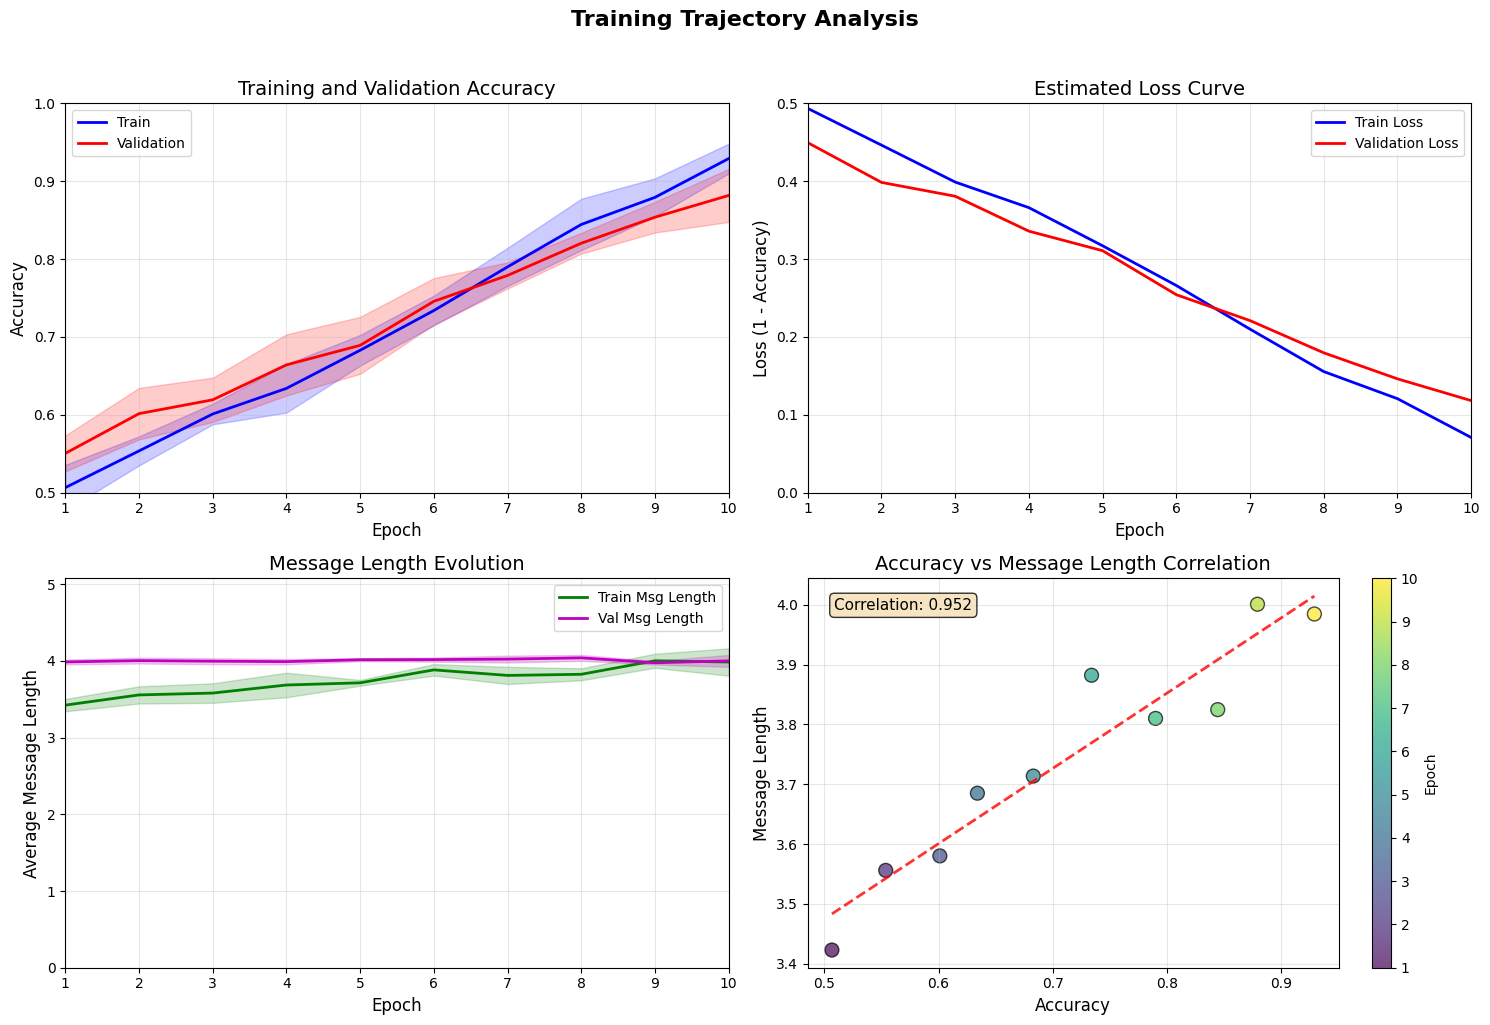


Test 2: Only train accuracy and message length


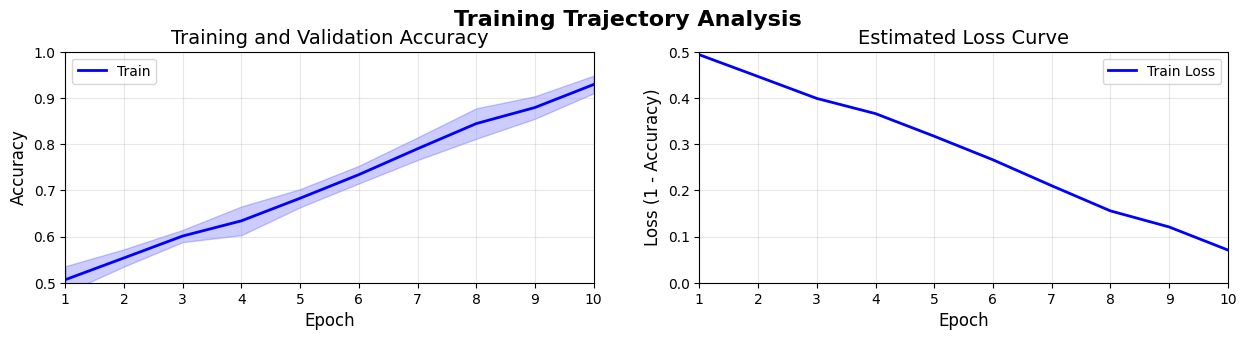

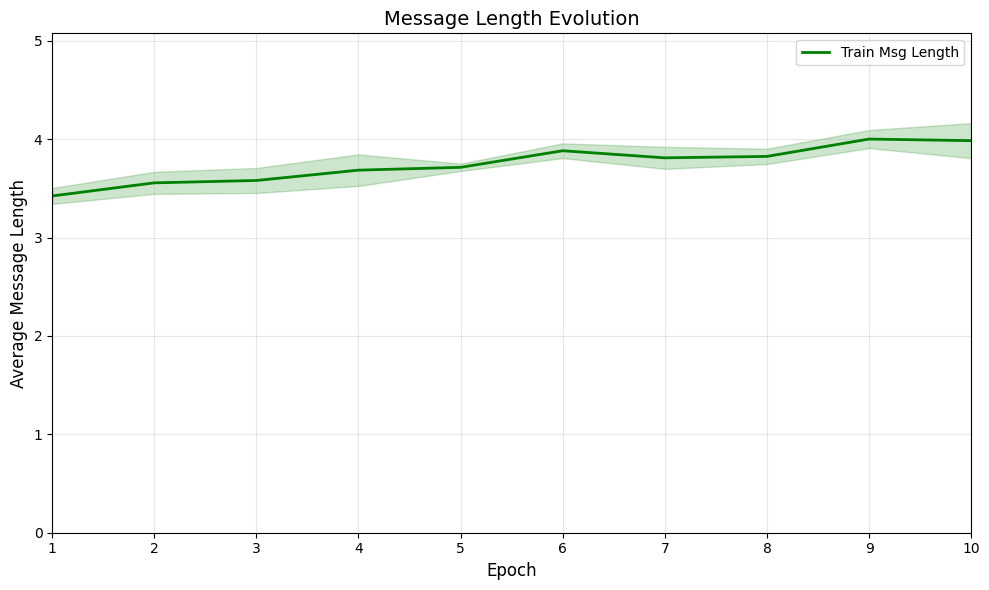


Test 3: Only accuracy (no message length)


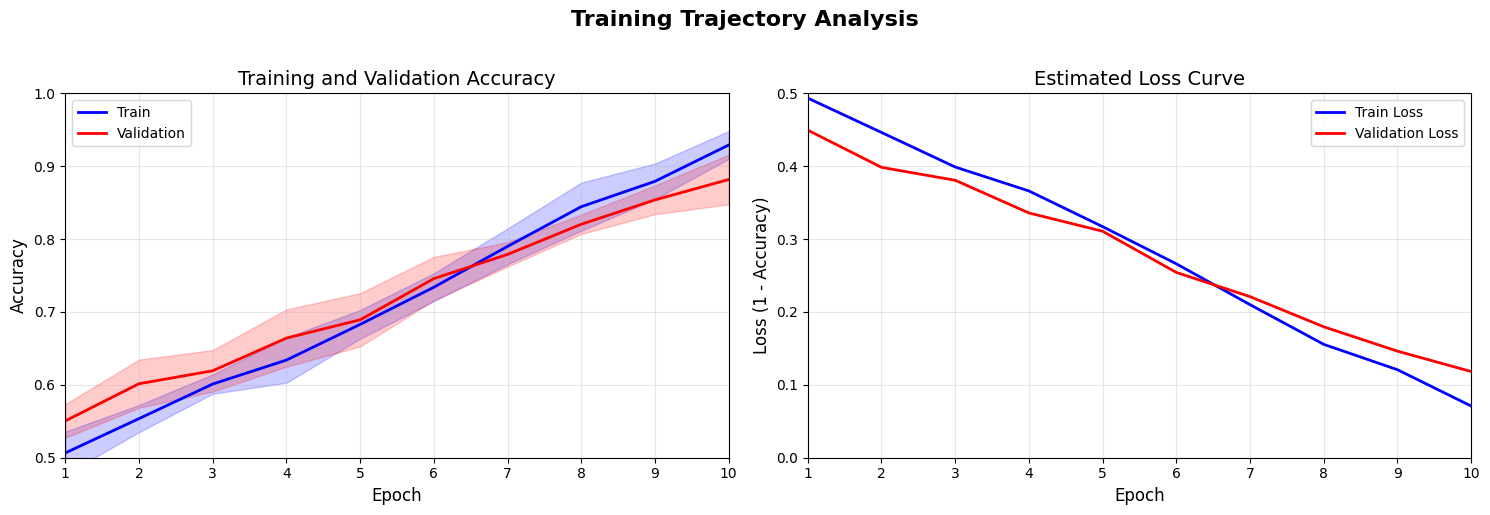


Test 4: Real data (single run)


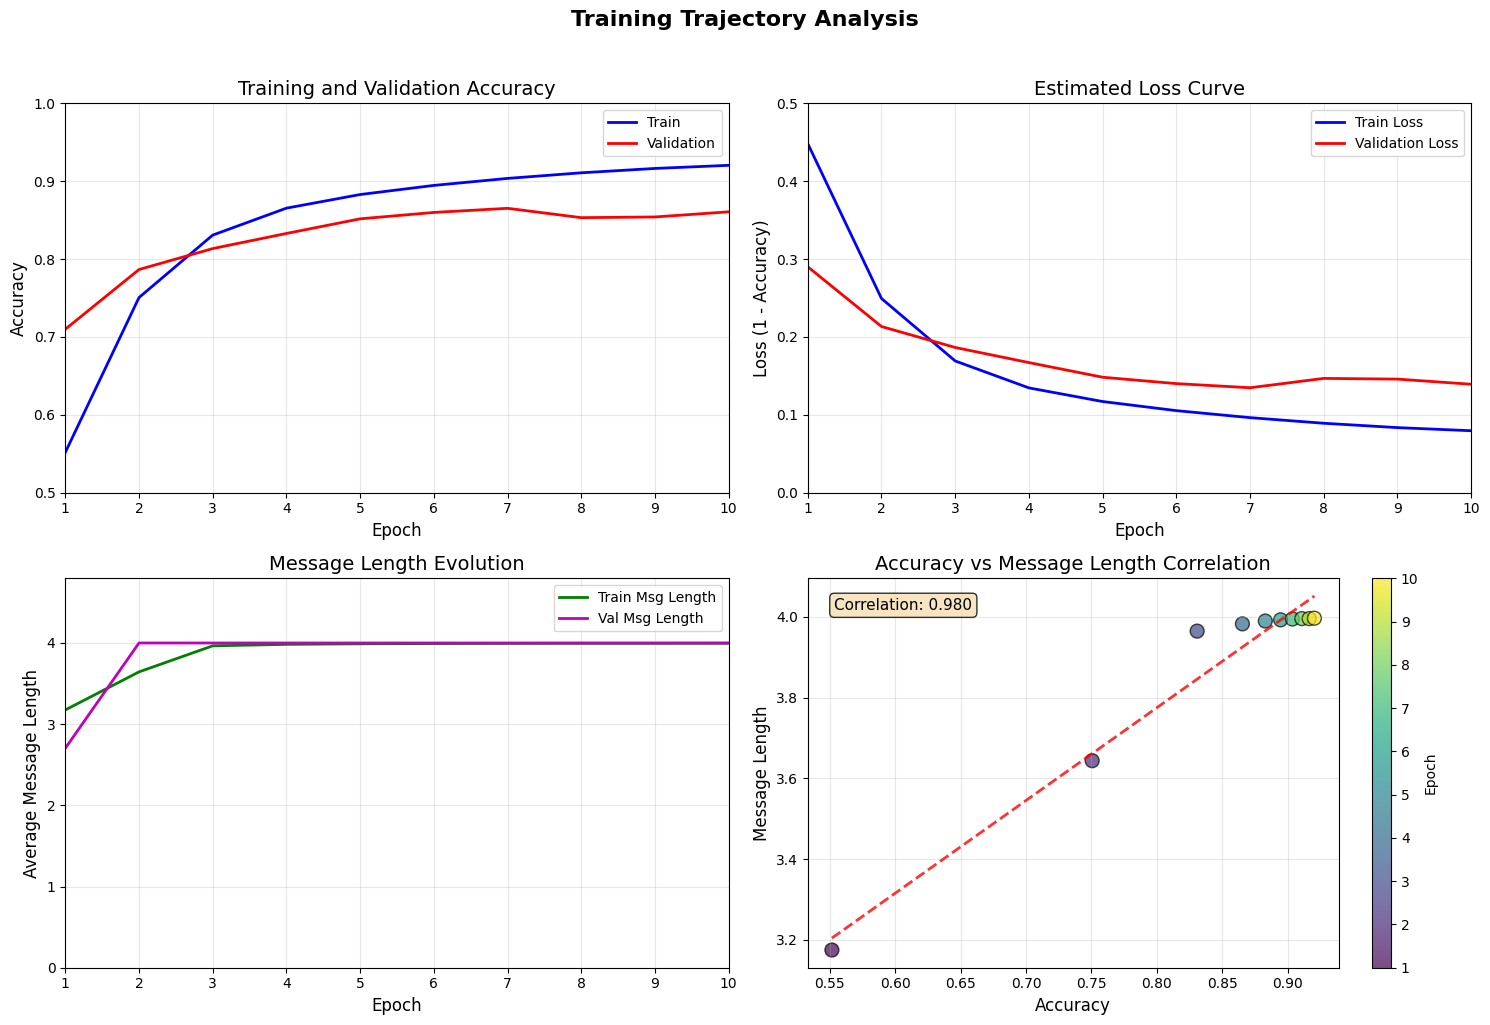


Test 5: Simple accuracy only (for quick analysis)


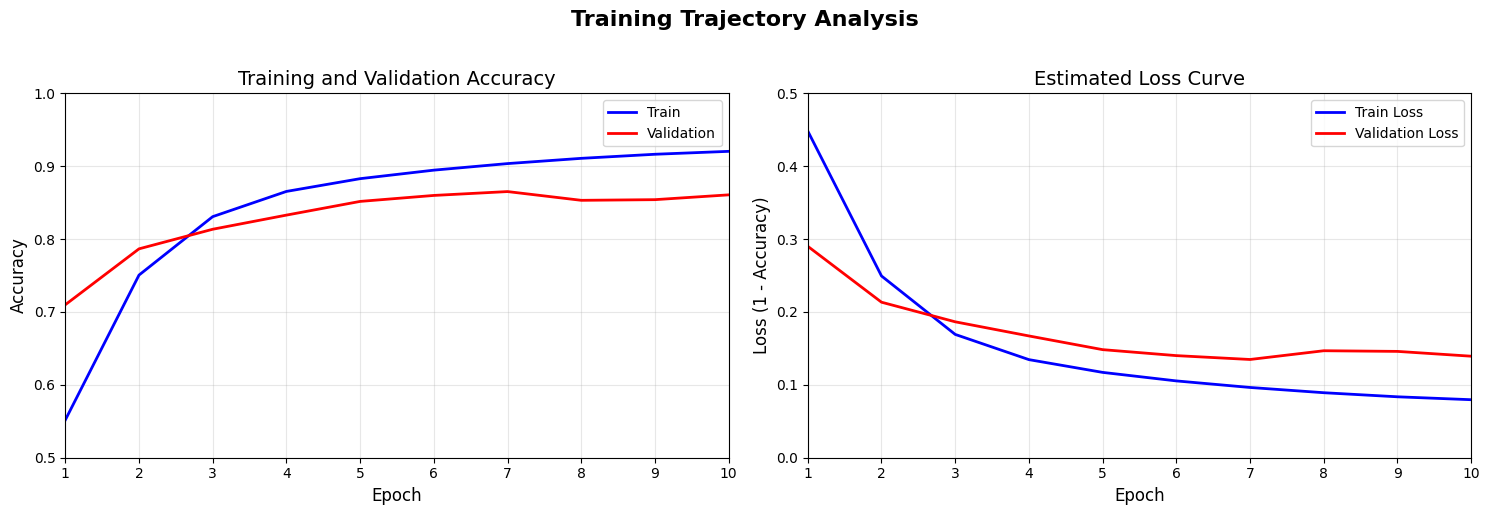

## 4) Analysis (50 points)
### 4.1) Model performance (10 points)
Assess the model performance for each dataset and condition.
### 4.2) Quantitative analysis (25 points)
Analyze the emerging languages in your conditions with metrics as you see fit. You can check out the emergent-abstractions github repository for inspiration. Your analysis should at least include the following metrics:
- NMI
- message length

Choose two additional metrics or types of quantitative analysis and interpret all your results.

### 4.3) Qualitative analysis (15 points)
Look at the emerging messages and concepts from the interaction files (see tutorial). Assess the differences between simulations with and without the hierarchical datasets. Can you make out specific test cases where the results (should) differ? Come up with a good way to visualize your results, either as a tidy table, or a visual representation, for example with clustering methods.

## 5) Discussion (20 points)
Summarize your results and discuss whether the hierarchical dataset implementation resulted in measurable differences in the emerging language.

## Bonus task (15 bonus points)
You receive 15 bonus points for trying to replicate the above-mentioned study by [Hawkins et al. (2018)](https://escholarship.org/uc/item/81s4d7fv) with a hierarchical dataset. This can be done in the scope of the assignments above. Suitable parameters for creating datasets with different context granularities are implemented in the main Github repository and can be used for this task. Make sure to present an analysis and discussion linking the simulation results to results from the paper.

## X) Reflection (no points, but mandatory)

Reflect on your group work. What went well? What did not go well?

Please note down the group members' team roles anonymously and reflect on how you filled this role.